ValueError: Could not interpret value `Delay (s)` for `hue`. An entry with this name does not appear in `data`.

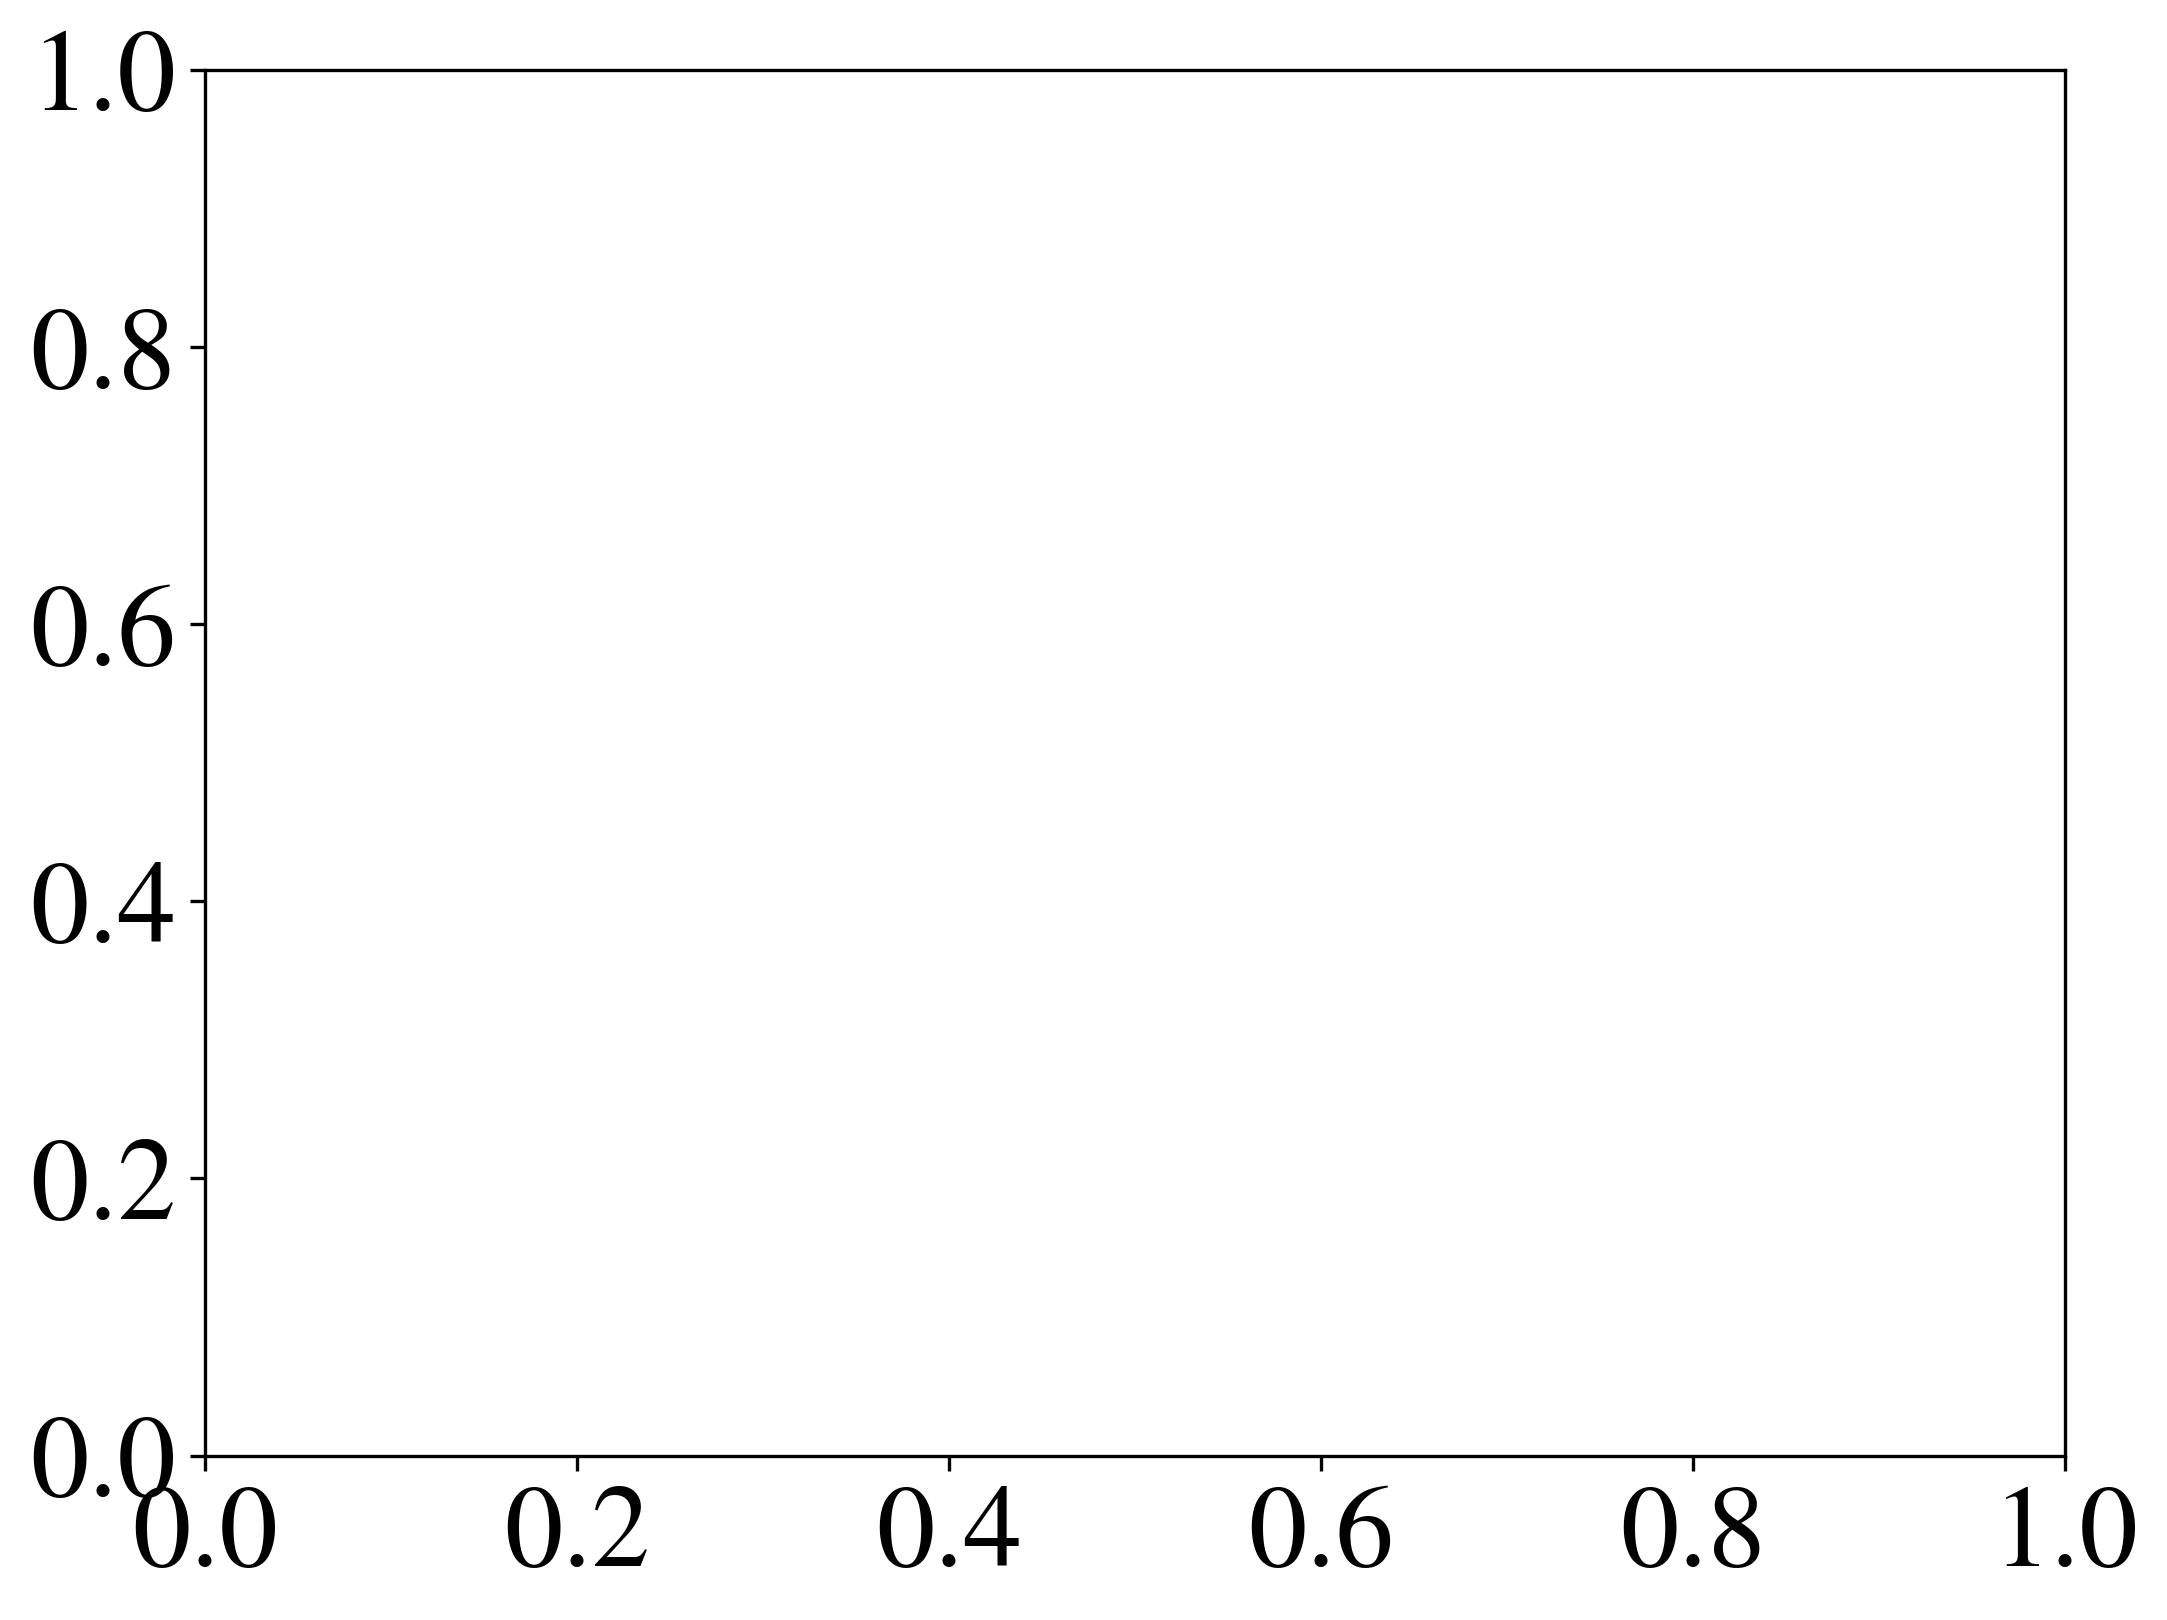

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import sys
import os
sys.path.insert(0, os.environ['PLOT_SETTINGS_DIR'])
import plot_settings

df = pd.concat([
    pd.read_csv("qcqp1_experiment_new_distance.csv"),
    pd.read_csv("qcqp1_experiment_new_distance_lower_q.csv")
    ])

df['variables'] = df['benchmark'].str.extract(r'_c_(\d+)').astype(int)
df['constraints'] =  df['benchmark'].str.extract(r'_c_\d+_(\d+)').astype(int)
df['gap'] =  (df['objective'] - df['ipopt_objective']) / np.abs(df['ipopt_objective']) * 100
for i, (v, sdf)in enumerate(df.groupby('variables')):
    fig, ax = plt.subplots(figsize=(8,6))
    
    sns.ecdfplot(sdf, 
                 ax=ax,
                 x='gap', hue='Delay (s)', palette='tab10', 
                 linewidth=3,
                 legend=i==0)
    ax.grid()
    ax.set_title(f'{v} Variables')
    ax.set_xlabel('Optimality Gap (% of Ipopt)')
    fig.savefig(f'delay_v{i}.pdf', bbox_inches='tight')
    # if i != 
# df.variables

In [2]:
df.columns

Index(['benchmark', 'bits', 'distance', 'dual_status', 'ipopt_objective',
       'objective', 'primal_status', 'random', 'time', 'variables',
       'constraints', 'gap'],
      dtype='object')

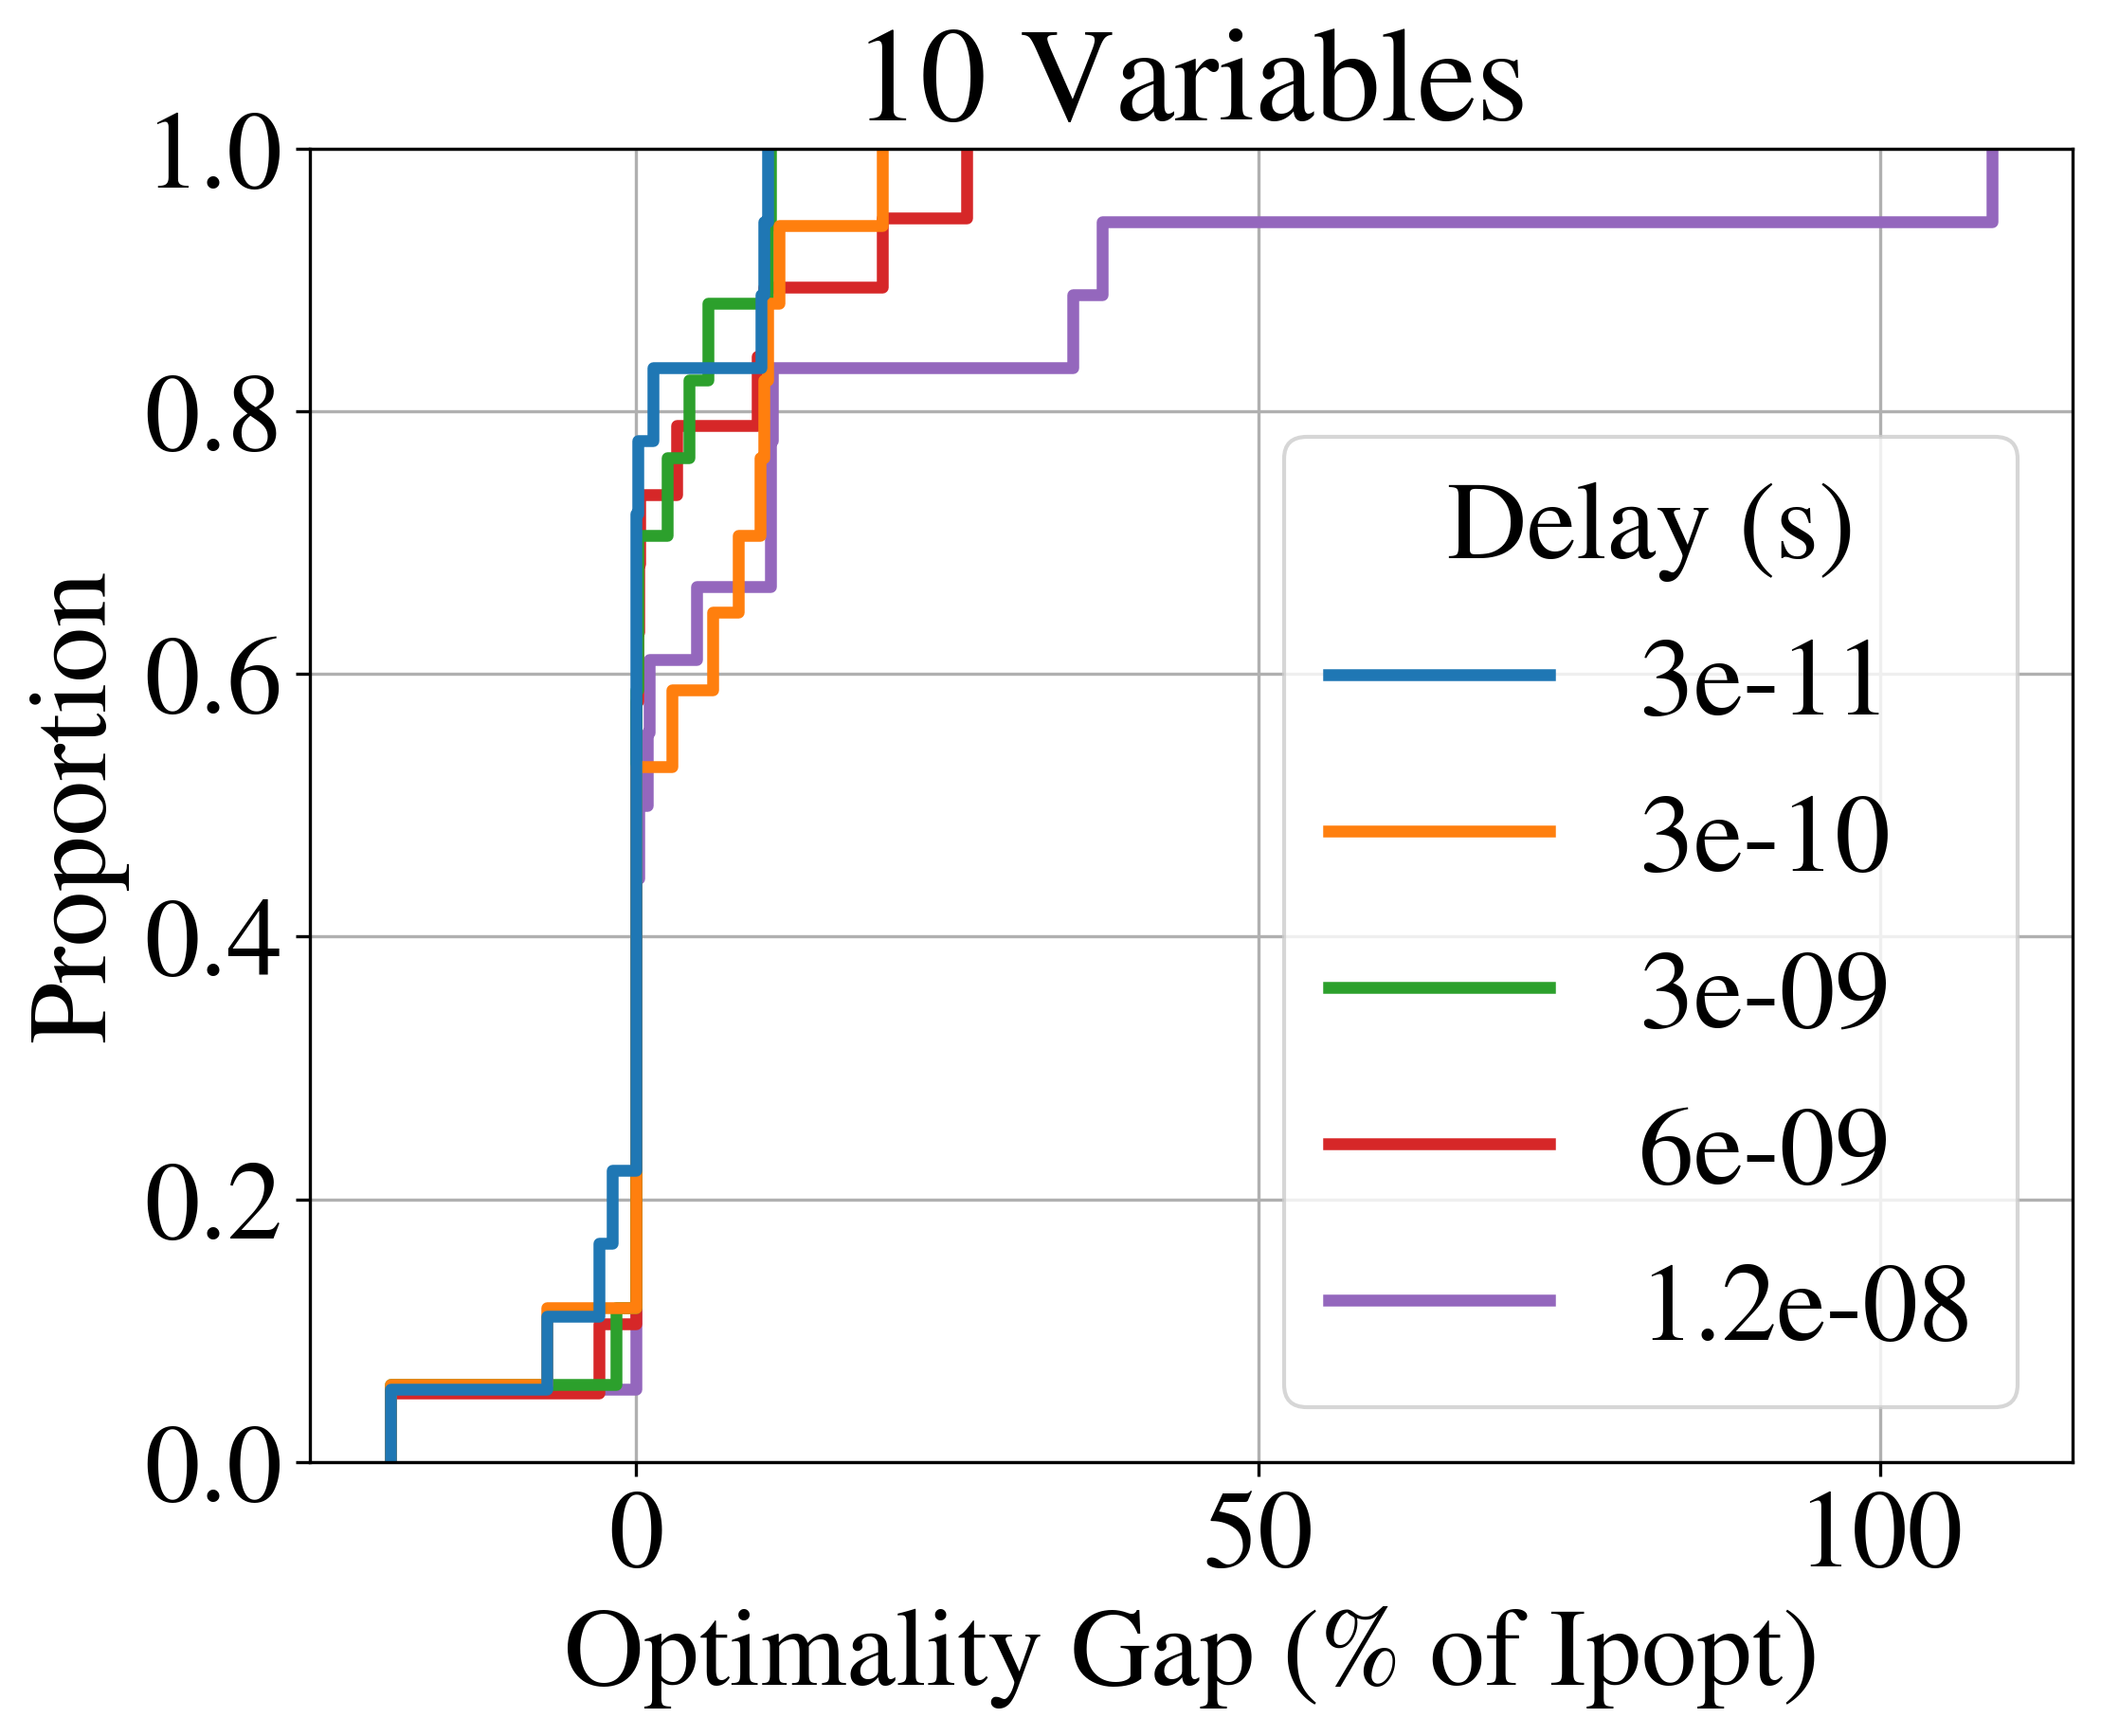

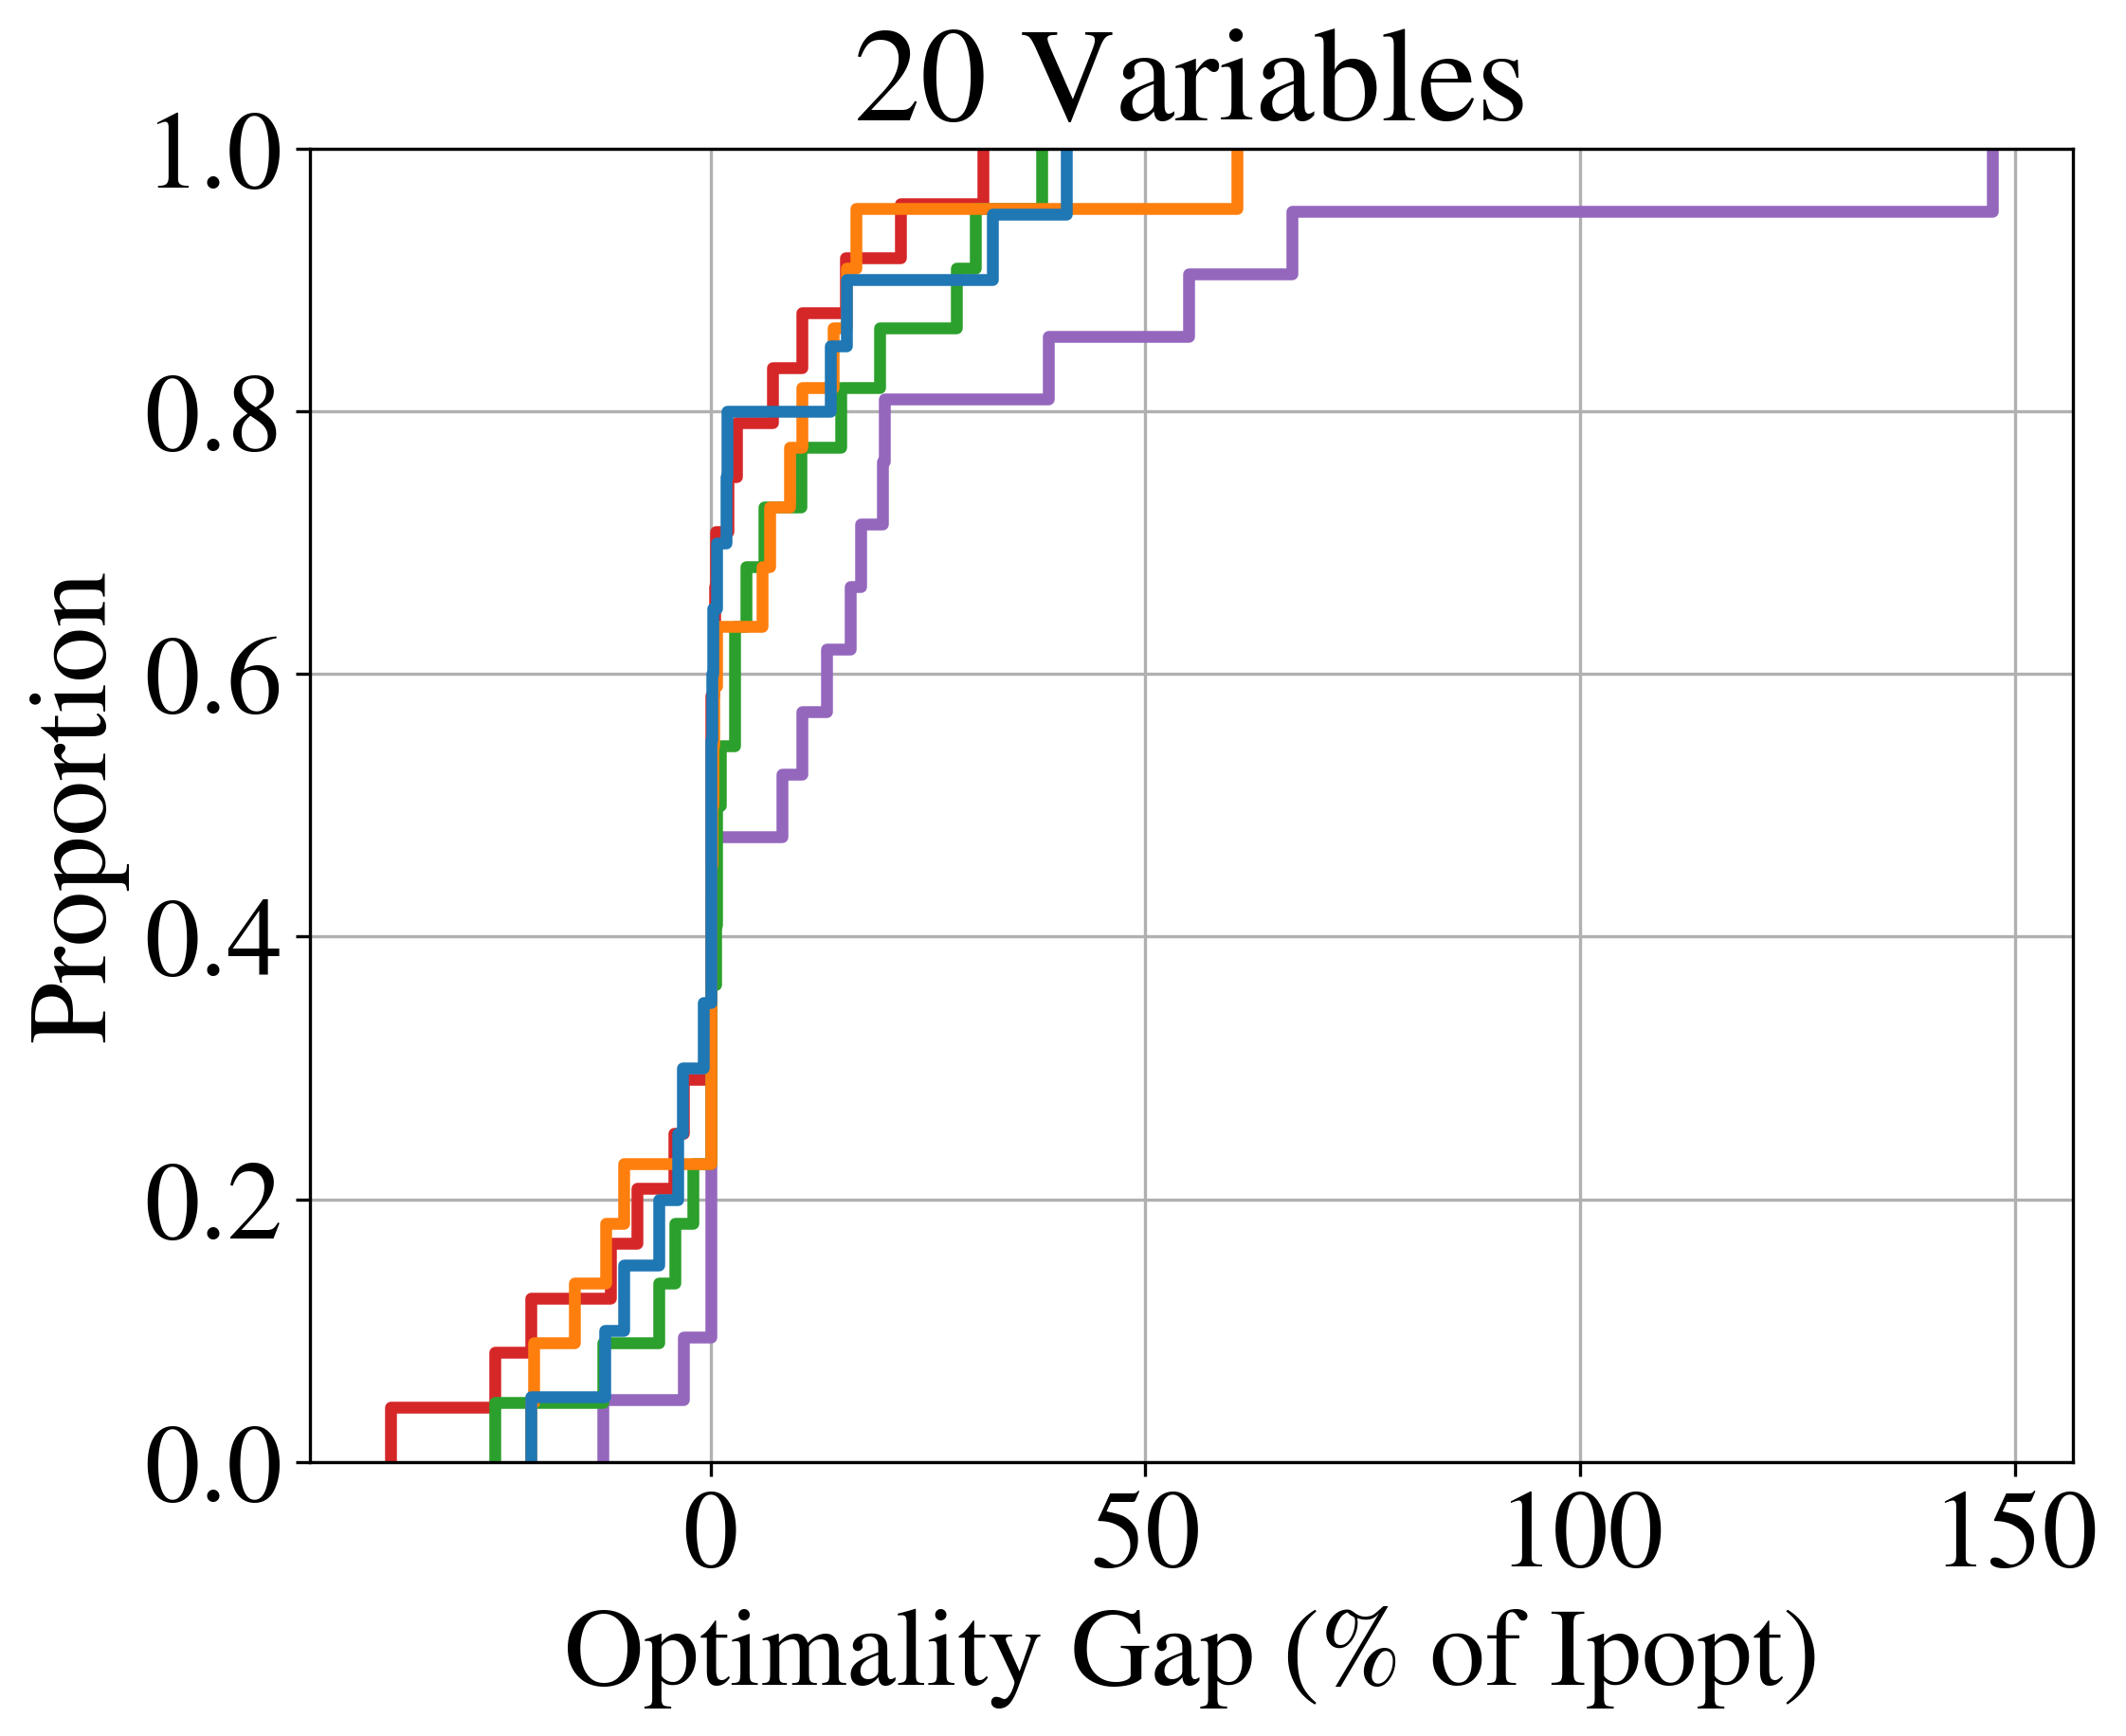

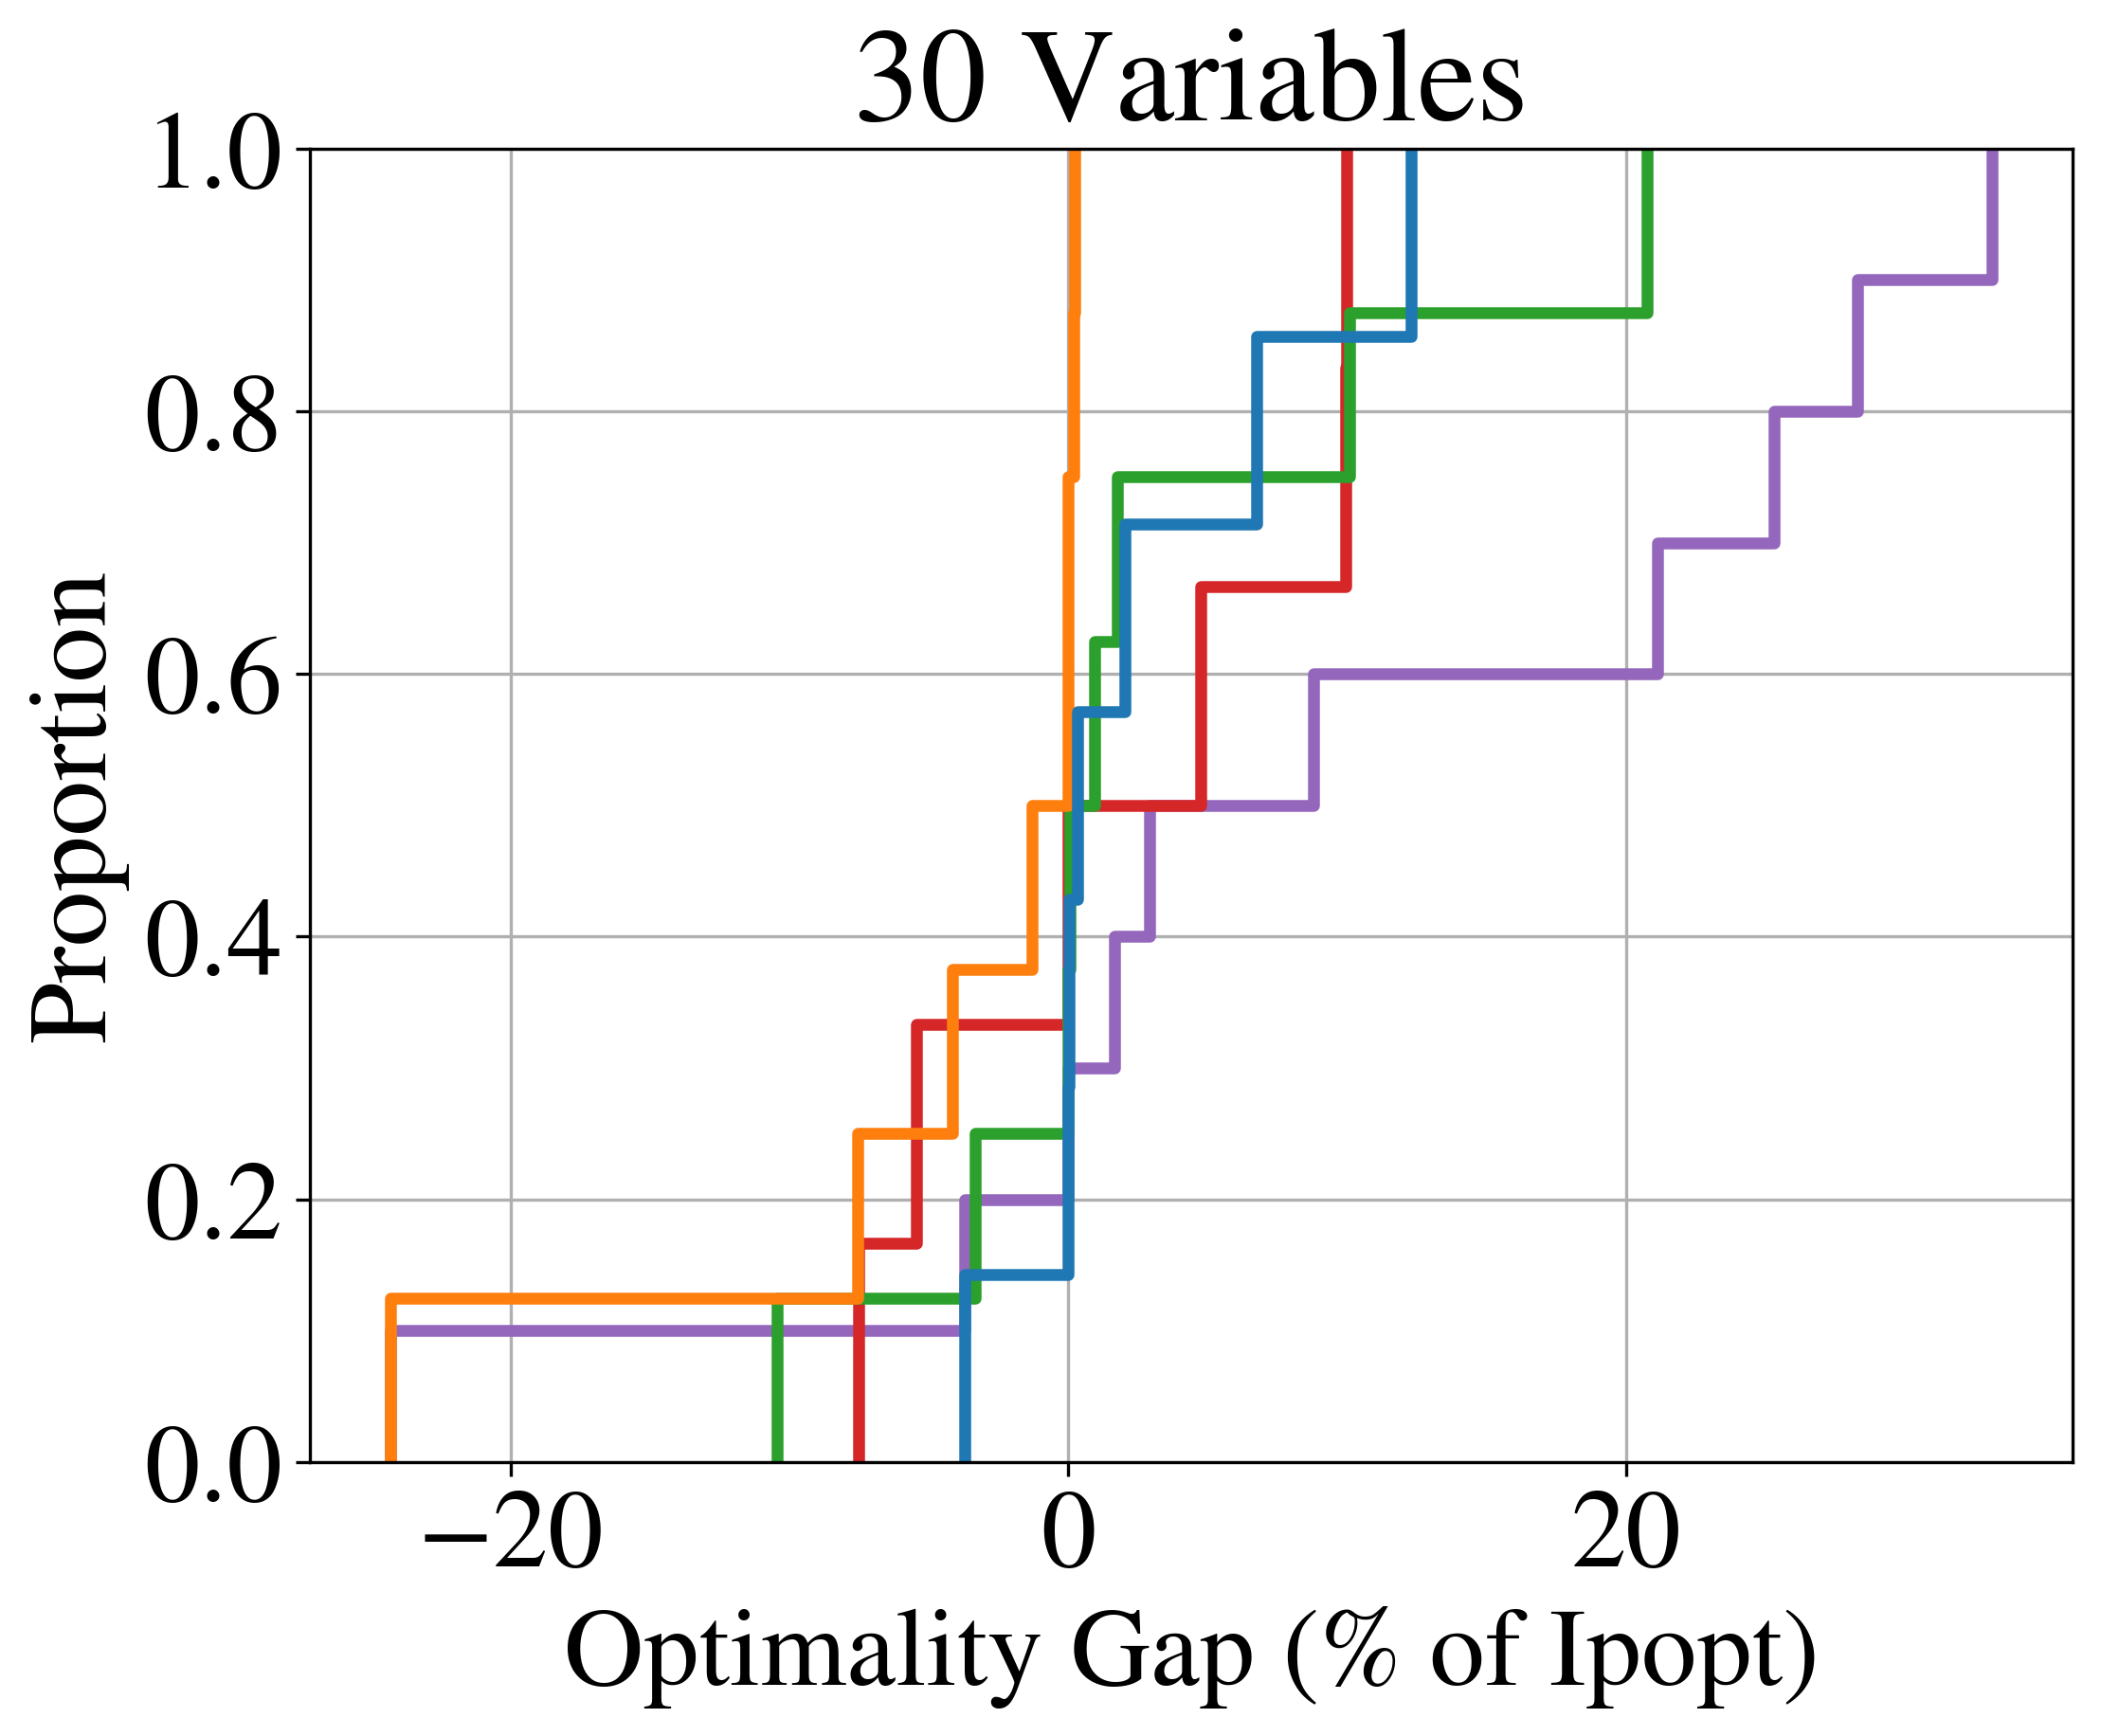

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

df = pd.concat([
    pd.read_csv("qcqp1_experiment_delay.csv"),
    pd.read_csv("qcqp1_experiment_delay_30.csv")
    ])
df['Delay (s)'] = 3e-8 * df['delay']
df['variables'] = df['benchmark'].str.extract(r'_c_(\d+)').astype(int)
df['constraints'] =  df['benchmark'].str.extract(r'_c_\d+_(\d+)').astype(int)
df['gap'] =  (df['objective'] - df['ipopt_objective']) / np.abs(df['ipopt_objective']) * 100
for i, (v, sdf)in enumerate(df.groupby('variables')):
    fig, ax = plt.subplots(figsize=(8,6))
    
    sns.ecdfplot(sdf.query("primal_status == True"), 
                 ax=ax,
                 x='gap', hue='Delay (s)', palette='tab10', 
                 linewidth=3,
                 legend=i==0)
    ax.grid()
    ax.set_title(f'{v} Variables')
    ax.set_xlabel('Optimality Gap (% of Ipopt)')
    fig.savefig(f'delay_v{i}.pdf', bbox_inches='tight')
    # if i != 
# df.variables
mean_df = 

In [23]:
df

,benchmark,bits,distance,dual_status,ipopt_objective,objective,primal_status,random,time,variables,constraints,gap
0,unitbox_c_10_10_1_100.jl,0,0.004260,True,-14.179042,-14.178933,True,False,4.68000,10,10,0.000109
1,unitbox_c_10_10_1_100.jl,0,0.004874,True,-14.179042,-14.179021,True,True,5.43000,10,10,0.000021
2,unitbox_c_10_10_1_100.jl,0,1.836437,True,-14.179042,-12.625623,True,True,2.61000,10,10,1.553419
3,unitbox_c_10_10_1_100.jl,0,0.002656,True,-14.179042,-14.179026,True,True,5.25000,10,10,0.000016
4,unitbox_c_10_10_1_100.jl,0,0.003774,True,-14.179042,-14.178910,True,True,4.20000,10,10,0.000132
...,...,...,...,...,...,...,...,...,...,...,...,...
1927,unitbox_c_20_20_1_50.jl,32,2.239863,True,-25.541802,-26.340000,True,True,1.14000,20,20,-0.798198
1928,unitbox_c_20_20_1_50.jl,32,2.648959,True,-25.541802,-23.810000,True,True,0.69000,20,20,1.731802
1929,unitbox_c_20_20_1_50.jl,32,0.119150,False,-25.541802,-25.612466,False,True,10.00002,20,20,-0.070664
1930,unitbox_c_20_20_1_50.jl,32,0.071643,False,-25.541802,-25.506994,True,True,10.00002,20,20,0.034808


In [ ]:
# import shutil
# import re
# import os
# pattern = re.compile(r'@objective\(m, (Min|Max), ([\w\[\]]+)\)')
# for folder in ["qcqp"]:#os.listdir('instances'):
#     if not os.path.isdir(f'instances/{folder}'):
#         continue
#     for filename in os.listdir(f'instances/{folder}'):
#         outlines = []
#         with open(f'instances/{folder}/{filename}') as infile:
#             instr = infile.read()
#             values = pattern.findall(instr)
#             if values == []:
#                 continue
#             values = values[0]
#             pattern2 = re.compile(r',\s*-(\(.*\))\+'+f'{values[-1]}'.replace('[', '\[').replace(']', '\]'))
#             found = False
#             if values == []:
#                 continue
#             for line in instr.splitlines():
#                 if "+{}".format(values[-1]) in line:
#                     found = True
#                     outlines.append(f'@objective(m, Min, {pattern2.findall(line)[0]})')
#                     print(outlines[-1])
#                 elif 'objective' in line:
#                     continue
#                 else:
#                     outlines.append(line.strip().replace('NLcon', 'con'))
#         with open(f'instances/{folder}/{filename}', 'w') as newfile:
#             newfile.write('\n'.join(outlines))
#         # break
#     # break
#         # assert found,f"{folder} {filename} {values}"

@objective(m, Min, (-1.36*x[3]*x[6]-0.3*x[3]*x[8]+1.7*x[3]*x[9]+1.77*x[4]*x[6]-0.64*x[4]*x[8]-0.99*x[4]*x[9]+1.66*x[5]*x[6]+0.69*x[5]*x[9]+0.56*x[3]-0.23*x[4]+0.72*x[5]+0.84*x[6]-0.06*x[8]-0.19*x[9]))
@objective(m, Min, (1.75*x[2]*x[20]-0.26*x[2]*x[19]-0.81*x[2]*x[21]-0.2*x[2]*x[23]+1.41*x[2]*x[25]+0.27*x[2]*x[27]+1.99*x[2]*x[28]-1.22*x[2]*x[29]+1.37*x[3]*x[18]+0.64*x[3]*x[20]+1.42*x[3]*x[21]+1.33*x[3]*x[23]-1.93*x[3]*x[24]-1.25*x[3]*x[26]+0.39*x[4]*x[16]-1.5*x[4]*x[17]-0.53*x[4]*x[19]+0.23*x[4]*x[22]-0.5*x[4]*x[23]+0.7*x[4]*x[24]-0.31*x[4]*x[27]-0.06*x[4]*x[28]+1.14*x[5]*x[17]+1.71*x[5]*x[18]+1.23*x[5]*x[19]-0.7*x[5]*x[20]-0.46*x[5]*x[21]+1.04*x[5]*x[23]-0.04*x[5]*x[27]+1.18*x[6]*x[17]+0.81*x[6]*x[19]+0.96*x[6]*x[20]+0.42*x[6]*x[24]+0.8*x[6]*x[27]-0.17*x[6]*x[28]+0.9*x[7]*x[20]+0.33*x[7]*x[23]+0.78*x[7]*x[24]+0.04*x[8]*x[16]+2*x[8]*x[18]-1.54*x[8]*x[21]-0.91*x[8]*x[23]+0.46*x[8]*x[24]-0.9*x[8]*x[25]+1.35*x[8]*x[26]-1.41*x[8]*x[27]+1.45*x[8]*x[29]+0.47*x[9]*x[18]-0.85*x[9]*x[16]-0.76*x

<>:16: SyntaxWarning: invalid escape sequence '\['
<>:16: SyntaxWarning: invalid escape sequence '\]'
<>:16: SyntaxWarning: invalid escape sequence '\['
<>:16: SyntaxWarning: invalid escape sequence '\]'
/tmp/ipykernel_444857/3414155809.py:16: SyntaxWarning: invalid escape sequence '\['
  pattern2 = re.compile(r',\s*-(\(.*\))\+'+f'{values[-1]}'.replace('[', '\[').replace(']', '\]'))
/tmp/ipykernel_444857/3414155809.py:16: SyntaxWarning: invalid escape sequence '\]'
  pattern2 = re.compile(r',\s*-(\(.*\))\+'+f'{values[-1]}'.replace('[', '\[').replace(']', '\]'))


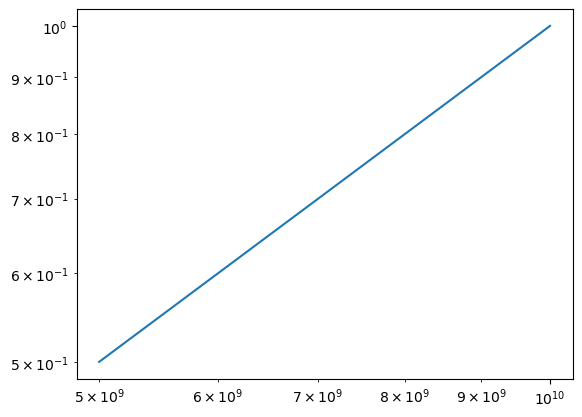

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
# df = pd.read_csv('test.csv')
# ax=sns.boxplot(df,
#                    x='bits',
#                    hue='N',
#                    y='dist',
#                    palette=sns.color_palette())
# ax.set_ylim(1e-7, 1)
# ax.set_yscale('log')
x = np.linspace(5e9, 10e9, 50)
P = 10e3 # per cm sq
Ic = 160e-6
hbar = 6.626e-34 / (2 * np.pi)
e = 1.6e-19
phi_0 = np.pi * hbar / e
def get_flux(I_dc):
    return I_dc / P
get_flux = np.vectorize(get_flux)
Lsquid = hbar / (2 * e * Ic)  / np.abs(np.cos(np.pi * get_flux(10e-6) / phi_0))
w0 = 7.5e9 * x * (1 + (Lsquid + 7.5e-12 / 2) / 101e-12)
w0 /= w0.max()
ax=sns.lineplot(x=x, y=w0)
ax.set_xscale('log')
ax.set_yscale('log')
